# Clustering

In [1]:
import numpy as np
import pandas as pd

In [6]:
#load data
data = pd.read_csv('marketing_campaign.csv', sep='\t')

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [8]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [9]:
data['Marital_Status'].value_counts()

Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: Marital_Status, dtype: int64

In [10]:
data['Education'].value_counts()

Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: Education, dtype: int64

## Feature engineering

In [28]:
from datetime import datetime

In [12]:
data["Age"] = 2025 - data["Year_Birth"]

In [14]:
data["Age"].max()

132

In [15]:
data["Age"].min()

29

In [19]:
data['TotalSpent'] = data["MntWines"] + data["MntFruits"] + data["MntMeatProducts"] + data["MntFishProducts"] + data['MntSweetProducts']\
                    + data["MntGoldProds"]

In [69]:
data["Is_Single"] = data['Marital_Status'].apply(lambda x: 'No' if x in ['Married', 'Together'] else 'Yes')

In [23]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'TotalSpent', 'Is_Single'],
      dtype='object')

In [25]:
data['RegistryDate'] = pd.to_datetime(data['Dt_Customer'], dayfirst=True)

In [31]:
data['Tenure'] = datetime.now().year-data['RegistryDate'].dt.year

In [48]:
#Length of being a member since last purchase in month
data['Tenure_Month'] = (datetime.now().year-data['RegistryDate'].dt.year)*12 + (datetime.now().month-data['RegistryDate'].dt.month)
data['Tenure_Month'] = data['Tenure_Month']-data['Recency']/30

In [53]:
data['FamilySize'] = data['Is_Single'].apply(lambda x: 1 if x==1 else 2)
data['FamilySize'] = data['FamilySize'] + data['Kidhome'] + data['Teenhome']

In [35]:
data['EducationLevel'] = data['Education'].replace({"Graduation": "Bachelor", "2n Cycle": "Master", "Basic":"Bachelor"})

In [55]:
data['MonthlySpent'] = data['TotalSpent']/24

In [64]:
data['TotalNumPurchases'] =data['NumDealsPurchases'] + data['NumWebPurchases'] + data['NumCatalogPurchases']\
                + data['NumStorePurchases']

In [58]:
data['MonthlyNumPurchases'] = data['TotalNumPurchases']/24

In [61]:
Mntfeatures = ['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']
for Mntfeature in Mntfeatures:
    data[f'{Mntfeature}_Percentage'] = data[Mntfeature]/data['TotalSpent']

In [65]:
Numfeatures = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
for Numfeature in Numfeatures:
    data[f'{Numfeature}_Percentage']=data[Numfeature]/data['TotalNumPurchases']

In [66]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntWines_Percentage,MntFruits_Percentage,MntMeatProducts_Percentage,MntFishProducts_Percentage,MntSweetProducts_Percentage,MntGoldProds_Percentage,NumDealsPurchases_Percentage,NumWebPurchases_Percentage,NumCatalogPurchases_Percentage,NumStorePurchases_Percentage
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0.392703,0.054422,0.337662,0.106370,0.054422,0.054422,0.120000,0.320000,0.400000,0.160000
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0.407407,0.037037,0.222222,0.074074,0.037037,0.222222,0.333333,0.166667,0.166667,0.333333
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0.548969,0.063144,0.163660,0.143041,0.027062,0.054124,0.047619,0.380952,0.095238,0.476190
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0.207547,0.075472,0.377358,0.188679,0.056604,0.094340,0.250000,0.250000,0.000000,0.500000
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0.409953,0.101896,0.279621,0.109005,0.063981,0.035545,0.263158,0.263158,0.157895,0.315789


In [67]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'TotalSpent', 'Is_Single', 'RegistryDate', 'Tenure',
       'EducationLevel', 'Tenure_Month', 'FamilySize', 'MonthlySpent',
       'TotalNumPurchases', 'MonthlyNumPurchases', 'MntWines_Percentage',
       'MntFruits_Percentage', 'MntMeatProducts_Percentage',
       'MntFishProducts_Percentage', 'MntSweetProducts_Percentage',
       'MntGoldProds_Percentage', 'NumDealsPurchases_Percentage',
       'NumWebPurchases_Percentage', 'NumCatalogPurchases_Percentage',
       'NumStorePurchases

In [128]:
selected_columns = ['Age', 'TotalSpent', 'Is_Single', 'Tenure', 'EducationLevel', 'Income', 'Kidhome',\
       'Teenhome', 'Tenure_Month', 'FamilySize', 'MonthlySpent', 'MonthlyNumPurchases', 'MntWines_Percentage',\
       'MntFruits_Percentage', 'MntMeatProducts_Percentage','MntFishProducts_Percentage', 'MntSweetProducts_Percentage',\
       'MntGoldProds_Percentage', 'NumDealsPurchases_Percentage','NumWebPurchases_Percentage',\
        'NumCatalogPurchases_Percentage','NumStorePurchases_Percentage','NumWebVisitsMonth']

In [127]:
numerical_features = ['Age', 'TotalSpent', 'Tenure',  'Income', 'Kidhome',\
       'Teenhome', 'Tenure_Month', 'FamilySize', 'MonthlySpent', 'MonthlyNumPurchases', 'MntWines_Percentage',\
       'MntFruits_Percentage', 'MntMeatProducts_Percentage','MntFishProducts_Percentage', 'MntSweetProducts_Percentage',\
       'MntGoldProds_Percentage', 'NumDealsPurchases_Percentage','NumWebPurchases_Percentage',\
        'NumCatalogPurchases_Percentage','NumStorePurchases_Percentage','NumWebVisitsMonth']

In [214]:
categorical_features = ['Is_Single','EducationLevel']

In [80]:
#check duplicates
data[selected_columns].duplicated().sum()

204

In [83]:
data.drop_duplicates(inplace = True)

In [85]:
#check missing value
data.isnull().sum()

ID                                 0
Year_Birth                         0
Education                          0
Marital_Status                     0
Income                            24
Kidhome                            0
Teenhome                           0
Dt_Customer                        0
Recency                            0
MntWines                           0
MntFruits                          0
MntMeatProducts                    0
MntFishProducts                    0
MntSweetProducts                   0
MntGoldProds                       0
NumDealsPurchases                  0
NumWebPurchases                    0
NumCatalogPurchases                0
NumStorePurchases                  0
NumWebVisitsMonth                  0
AcceptedCmp3                       0
AcceptedCmp4                       0
AcceptedCmp5                       0
AcceptedCmp1                       0
AcceptedCmp2                       0
Complain                           0
Z_CostContact                      0
Z

In [86]:
len(data)

2240

In [87]:
data.dropna(subset=['Income','NumDealsPurchases_Percentage','NumWebPurchases_Percentage',\
                    'NumCatalogPurchases_Percentage','NumWebPurchases_Percentage'], inplace=True)

In [88]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntWines_Percentage,MntFruits_Percentage,MntMeatProducts_Percentage,MntFishProducts_Percentage,MntSweetProducts_Percentage,MntGoldProds_Percentage,NumDealsPurchases_Percentage,NumWebPurchases_Percentage,NumCatalogPurchases_Percentage,NumStorePurchases_Percentage
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0.392703,0.054422,0.337662,0.106370,0.054422,0.054422,0.120000,0.320000,0.400000,0.160000
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0.407407,0.037037,0.222222,0.074074,0.037037,0.222222,0.333333,0.166667,0.166667,0.333333
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0.548969,0.063144,0.163660,0.143041,0.027062,0.054124,0.047619,0.380952,0.095238,0.476190
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0.207547,0.075472,0.377358,0.188679,0.056604,0.094340,0.250000,0.250000,0.000000,0.500000
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0.409953,0.101896,0.279621,0.109005,0.063981,0.035545,0.263158,0.263158,0.157895,0.315789


In [93]:
#handle outliers
import seaborn as sns
import matplotlib.pyplot as plt

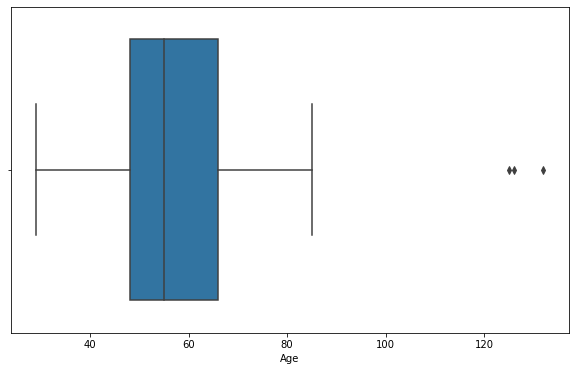

In [97]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data, x='Age')
plt.show()

In [102]:
def IQRFilter(feature):
    IQ1 = data[feature].quantile(0.25)
    IQ3 = data[feature].quantile(0.75)
    IQR = IQ3-IQ1
    lower_bound = IQ1-1.5*IQ1
    upper_bound = IQ3 + 1.5*IQ3
    return lower_bound, upper_bound

In [103]:
lower_bound, upper_bound = IQRFilter('Age')

In [104]:
lower_bound, upper_bound

(-24.0, 165.0)

In [105]:
data['Age'].min()

29

In [106]:
data['Age'].max()

132

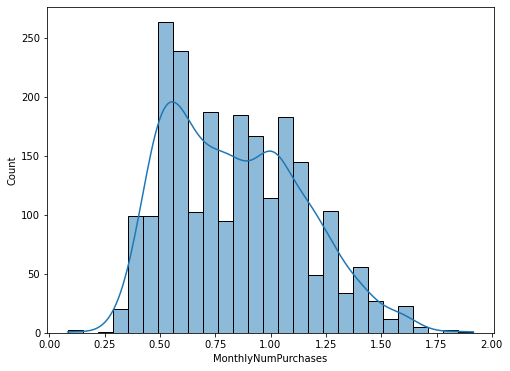

In [109]:
# EDA
#univariant 
plt.figure(figsize=(8,6))
sns.histplot(data['MonthlyNumPurchases'], kde=True)
plt.show()

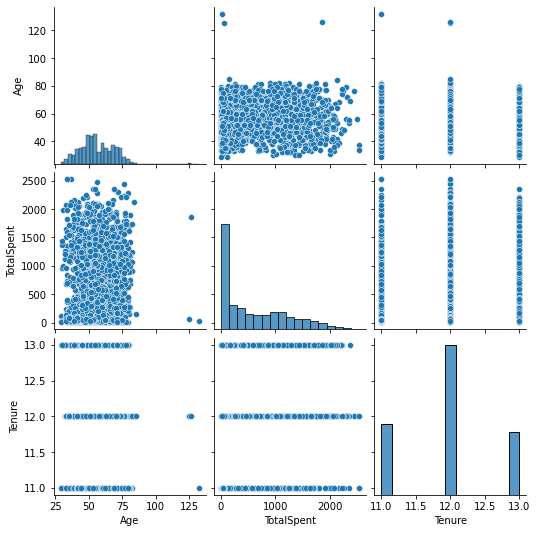

In [114]:
#multivariant
#plt.figure(figsize=(12,10))
sns.pairplot(data[numerical_features[:4]])
plt.show()

In [115]:
#data preprocessing
from sklearn.compose import ColumnTransformer

In [121]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [122]:
# reduce dimensions
from sklearn.decomposition import PCA

In [185]:
from sklearn.pipeline import Pipeline

In [140]:
preprocessor = ColumnTransformer([
    ('num_feature', StandardScaler(), numerical_features),
    ('cat_feature', OneHotEncoder(handle_unknown='error', drop='first'), categorical_features)
])

In [141]:
X = data[selected_columns].copy()

In [148]:
preprocessor.fit(X)

ColumnTransformer(transformers=[('num_feature', StandardScaler(),
                                 ['Age', 'TotalSpent', 'Tenure', 'Income',
                                  'Kidhome', 'Teenhome', 'Tenure_Month',
                                  'FamilySize', 'MonthlySpent',
                                  'MonthlyNumPurchases', 'MntWines_Percentage',
                                  'MntFruits_Percentage',
                                  'MntMeatProducts_Percentage',
                                  'MntFishProducts_Percentage',
                                  'MntSweetProducts_Percentage',
                                  'MntGoldProds_Percentage',
                                  'NumDealsPurchases_Percentage',
                                  'NumWebPurchases_Percentage',
                                  'NumCatalogPurchases_Percentage',
                                  'NumStorePurchases_Percentage',
                                  'NumWebVisitsMonth']),
         

In [149]:
X_preprocessed =preprocessor.transform(X)

In [150]:
X_preprocessed

array([[ 0.98677132,  1.67367862,  1.4991072 , ...,  1.        ,
         0.        ,  0.        ],
       [ 1.23708533, -0.96415679, -1.41864478, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.3192673 ,  0.27844618,  0.04023121, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.01574076,  1.04988862, -1.41864478, ...,  1.        ,
         0.        ,  0.        ],
       [ 1.07020933,  0.38960025, -1.41864478, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.23708533, -0.72359947,  1.4991072 , ...,  0.        ,
         0.        ,  1.        ]])

In [158]:
columns = numerical_features + preprocessor.named_transformers_['cat_feature'].get_feature_names(categorical_features).tolist()

In [159]:
X_preprocessed_df = pd.DataFrame(X_preprocessed, columns=columns)

In [160]:
X_preprocessed_df.head()

,Age,TotalSpent,Tenure,Income,Kidhome,Teenhome,Tenure_Month,FamilySize,MonthlySpent,MonthlyNumPurchases,...,MntSweetProducts_Percentage,MntGoldProds_Percentage,NumDealsPurchases_Percentage,NumWebPurchases_Percentage,NumCatalogPurchases_Percentage,NumStorePurchases_Percentage,NumWebVisitsMonth,Is_Single_Yes,EducationLevel_Master,EducationLevel_PhD
0,0.986771,1.673679,1.499107,0.238038,-0.823521,-0.930538,1.419147,-1.762071,1.673679,1.621992,...,0.061002,-0.602742,-0.545651,0.535743,2.024737,-2.101903,0.699446,1.0,0.0,0.0
1,1.237085,-0.964157,-1.418645,-0.234546,1.039084,0.907275,-1.170568,0.448137,-0.964157,-1.270433,...,-0.224618,0.937516,1.375947,-1.021994,0.190595,-0.643053,-0.131252,1.0,0.0,0.0
2,0.319267,0.278446,0.040231,0.777978,-0.823521,-0.930538,-0.064959,-0.656967,0.278446,0.657851,...,-0.388503,-0.605478,-1.197622,1.154967,-0.370877,0.559295,-0.546600,0.0,0.0,0.0
3,-1.266055,-0.921022,-1.418645,-1.023841,1.039084,-0.930538,-0.961399,0.448137,-0.921022,-0.857229,...,0.096851,-0.236332,0.625323,-0.175398,-1.119506,0.759687,0.284097,0.0,0.0,0.0
4,-1.015741,-0.308845,-1.418645,0.244249,1.039084,-0.930538,-1.150647,0.448137,-0.308845,0.520116,...,0.218054,-0.776014,0.743843,-0.041725,0.121643,-0.790710,-0.131252,0.0,0.0,1.0


In [ ]:
#dimension reduction

In [180]:
pca = PCA(n_components=0.95)

In [181]:
pca.fit(X_preprocessed_df[numerical_features])

PCA(n_components=0.95)

In [182]:
X_reduced = pca.fit_transform(X_preprocessed_df[numerical_features])

In [183]:
X_reduced.shape

(2212, 13)

In [184]:
len(numerical_features)

21

## Include PCA in preprocessor

In [187]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('PCA', PCA(n_components=0.95))
])

In [189]:
preprocessor = ColumnTransformer([
    ('num_feature', pipeline, numerical_features),
    ('cat_feature', OneHotEncoder(handle_unknown='error', drop='first'), categorical_features)
])

In [190]:
preprocessor.fit(X)

ColumnTransformer(transformers=[('num_feature',
                                 Pipeline(steps=[('scaler', StandardScaler()),
                                                 ('PCA',
                                                  PCA(n_components=0.95))]),
                                 ['Age', 'TotalSpent', 'Tenure', 'Income',
                                  'Kidhome', 'Teenhome', 'Tenure_Month',
                                  'FamilySize', 'MonthlySpent',
                                  'MonthlyNumPurchases', 'MntWines_Percentage',
                                  'MntFruits_Percentage',
                                  'MntMeatProducts_Percentage',
                                  'MntFishProducts_Percentage',
                                  'MntSweetProducts_Percentage',
                                  'MntGoldProds_Percentage',
                                  'NumDealsPurchases_Percentage',
                                  'NumWebPurchases_Percentage',
     

In [192]:
X_preprocessed = preprocessor.transform(X)

In [204]:
n_components = preprocessor.named_transformers_['num_feature'].named_steps['PCA'].n_components_

In [205]:
pca_columns = [f'PCA_{i}' for i in range(n_components)]

In [213]:
categorical_features

array(['Is_Single_Yes', 'EducationLevel_Master', 'EducationLevel_PhD'],
      dtype=object)

In [216]:
cat_features = preprocessor.named_transformers_['cat_feature'].get_feature_names(categorical_features).tolist()

In [217]:
columns = pca_columns+cat_features

In [218]:
X_preprocessed = pd.DataFrame(X_preprocessed, columns=columns)

In [219]:
X_preprocessed.head()

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,PCA_10,PCA_11,PCA_12,Is_Single_Yes,EducationLevel_Master,EducationLevel_PhD
0,3.569422,-0.259320,3.328104,0.774310,0.336231,0.368985,-0.545557,1.175886,0.279121,0.186886,1.370657,0.347540,-0.128357,1.0,0.0,0.0
1,-2.129527,0.383499,-1.920286,0.702159,-0.023157,1.871689,-1.163002,0.641051,-0.113859,0.060048,0.373992,0.333915,-0.216862,1.0,0.0,0.0
2,1.546064,-0.386899,-0.020897,0.284344,-1.123253,-1.432435,0.654538,0.220928,1.022107,-0.345010,-0.374487,0.688753,-0.007823,0.0,0.0,0.0
3,-2.666765,-2.035814,-1.166546,0.426088,1.273416,-0.426745,0.903221,-0.103229,1.219807,-0.118635,0.226415,-0.234555,0.089233,0.0,0.0,0.0
4,-0.634511,-0.792101,-0.765600,1.550796,1.256012,0.399948,0.773413,-1.161672,0.554679,-0.300759,0.937877,0.533425,-0.644205,0.0,0.0,1.0


## Clustering

In [223]:
#from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [ ]:
#use elbow method to find the best number of clusters

In [234]:
scores1 = []
scores2 = []
for i in range(2,10):
    model=KMeans(i)
    pred=model.fit_predict(X_preprocessed)
    score = silhouette_score(X_preprocessed, pred)
    scores1.append(score)
    scores2.append(model.inertia_)

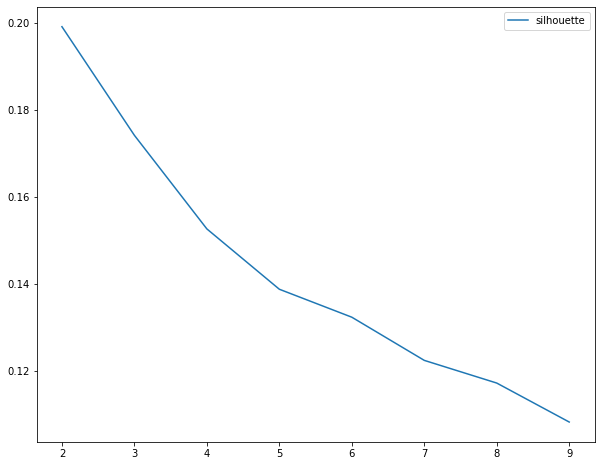

In [236]:
plt.figure(figsize=(10,8))
plt.plot(range(2,10), scores1, label='silhouette')
#plt.plot(range(2,5), scores2, label='distortion score')
plt.legend()
plt.show()

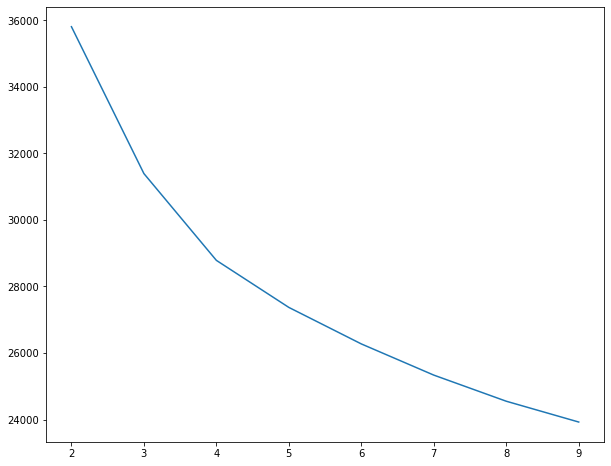

In [237]:
plt.figure(figsize=(10,8))
#plt.plot(range(2,5), scores1, label='silhouette')
plt.plot(range(2,10), scores2, label='distortion score')
plt.show()

In [238]:
model=KMeans(9)

In [239]:
pred = model.fit_predict(X_preprocessed)

In [240]:
len(pred)

2212

In [241]:
X.shape

(2212, 23)

In [242]:
data.shape

(2212, 50)

In [243]:
data['cluster']=pred

<Figure size 432x288 with 0 Axes>

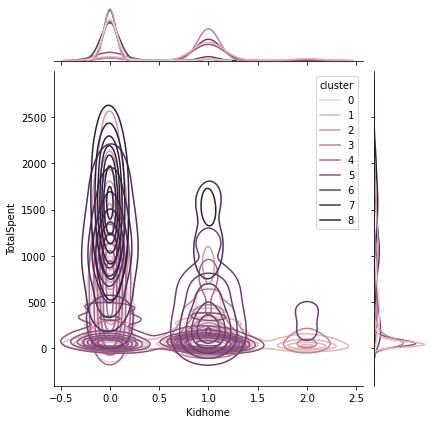

In [247]:
plt.figure()
sns.jointplot(x=data["Kidhome"], y=data["TotalSpent"], hue =data["cluster"], kind="kde")
plt.show()